In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
data=pd.read_csv("C:/Users/priya/OneDrive/Desktop/python datasets/Netflix movies and TV shows.csv")
data.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
np.shape(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
data["director"]=data["director"].replace(np.nan,"Unknown")
data["cast"]=data["cast"].replace(np.nan,"Not Available")
data["country"]=data["country"].replace(np.nan,"Not Mentioned")
data["rating"]=data["rating"].replace(np.nan,"Not Present")
data["date_added"]=data["date_added"].replace(np.nan,"Not Mentioned")
data.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Not Mentioned,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


The 3 nan values of duration goes to rating part so, that transfer again to duration

In [6]:
mask=data["duration"].isnull() & data["rating"].str.contains("min")
data.loc[mask,"duration"]=data.loc[mask,"rating"]
data.loc[mask,"rating"]="Not Mentioned"
data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

data["date_added"]=pd.to_datetime(data["date_added"],errors="coerce") print(data["date_added"].dtypes)

data["date_added"]=data["date_added"].dt.year print(data["date_added"].dtypes) data.head()

so this is for change full date to only year


In [8]:
a=data.query("type=='Movie'").copy()
a["duration"]=a["duration"].str.replace("min"," ")
a['duration'] = pd.to_numeric(a['duration'], errors='coerce').astype('Int64')
a.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Not Mentioned,"September 24, 2021",2021,PG,91,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127,"Dramas, International Movies",After most of her family is murdered in a terr...


In [9]:
b=data.query("type=='TV Show'").copy()
b["duration"]=b["duration"].str.replace("Seasons"," ").str.replace("Season"," ")
b['duration'] = pd.to_numeric(b['duration'], errors='coerce').astype('Int64')
b.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Mentioned,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Not Mentioned,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Not Mentioned,"September 24, 2021",2021,TV-MA,1,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [10]:
data["duration"] = data["duration"].str.extract(r'(\d+)')
data["duration"] = data["duration"].astype(int)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      8807 non-null   object
 4   cast          8807 non-null   object
 5   country       8807 non-null   object
 6   date_added    8807 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8807 non-null   object
 9   duration      8807 non-null   int64 
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(2), object(10)
memory usage: 825.8+ KB


In [11]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,"September 25, 2021",2020,PG-13,90,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Not Mentioned,"September 24, 2021",2021,TV-MA,1,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Not Mentioned,"September 24, 2021",2021,TV-MA,1,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data.describe()

,release_year,duration
count,8807.000000,8807.000000
mean,2014.180198,69.848530
std,8.819312,50.806431
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


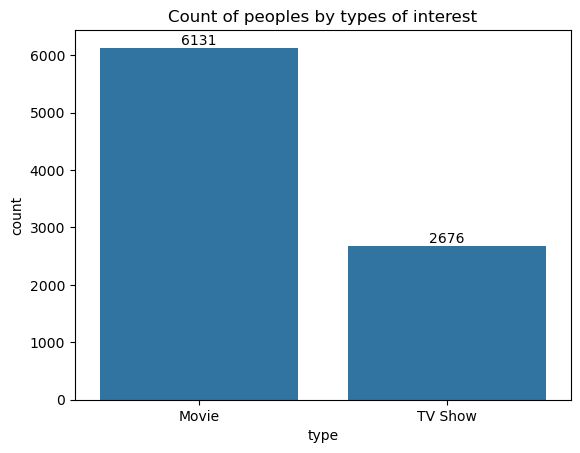

In [15]:
a=sns.countplot(data=data,x="type")
plt.title("Count of peoples by types of interest")
a.bar_label(a.containers[0])
plt.show()

         type
type         
Movie    6131
TV Show  2676


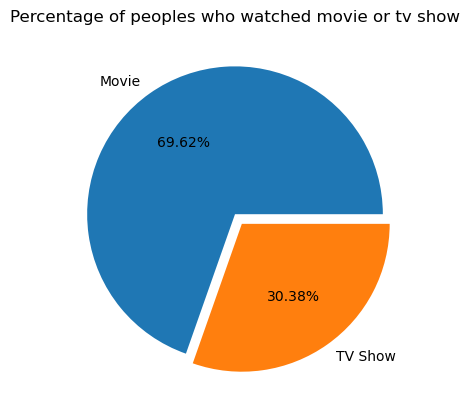

In [16]:
a=data.groupby("type").agg({"type":"count"})
print(a)
plt.pie(a["type"],labels=a.index,autopct="%.2f%%",explode=[0,0.08])
plt.title("Percentage of peoples who watched movie or tv show")
plt.show()

IT means movie viewers are greater than TV shows veiwers

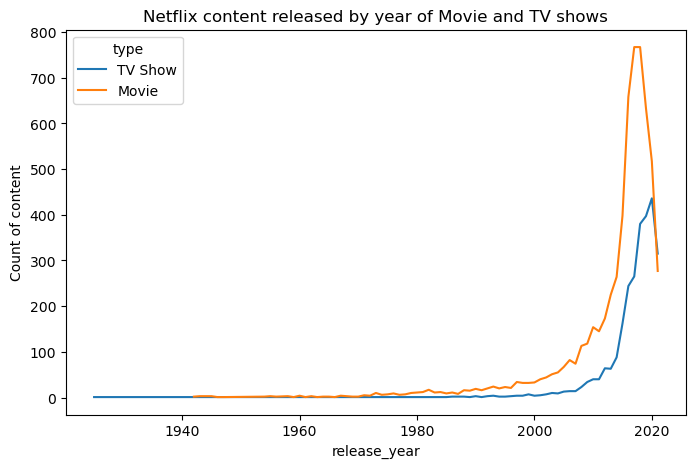

In [17]:
a = data.groupby(["release_year", "type"]).agg({"show_id":"count"})
plt.figure(figsize=(8,5))
plt.ylabel("Count of content")
plt.title("Netflix content released by year of Movie and TV shows")
sns.lineplot(data=a, x="release_year", y="show_id", hue="type")
plt.show()

it shows that in netflix from 1940 content production increased slowly and then there is sudden highly increase of that after 2000 for both type but
movie production is greater than TV show production and reach on highest production by roughly 2015 and then sudden downfall again till 2020

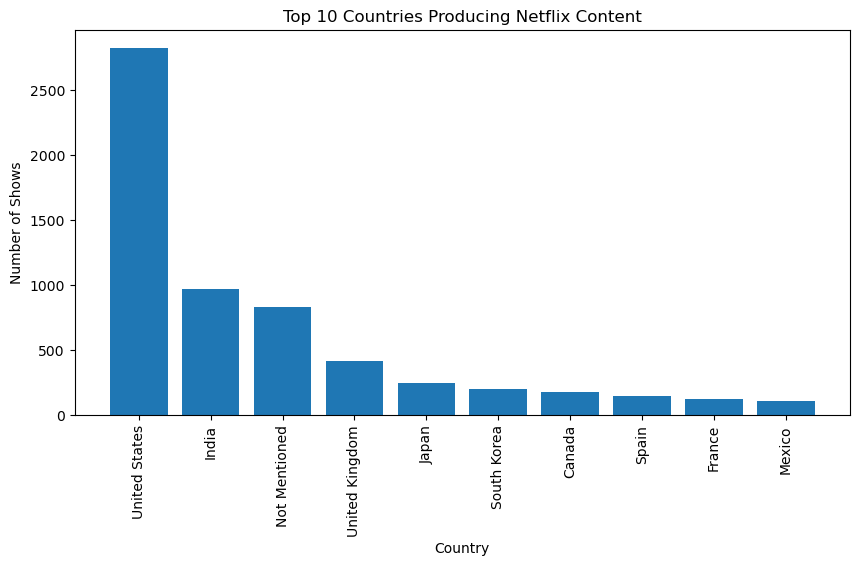

In [37]:
a = data.groupby("country")["show_id"].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(a.index, a.values)
plt.xticks(rotation=90)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.show()

It shows that which movies or tv shows released in united stataes that were most produced by netflix so, peoples love to watch english or hollywood
movies

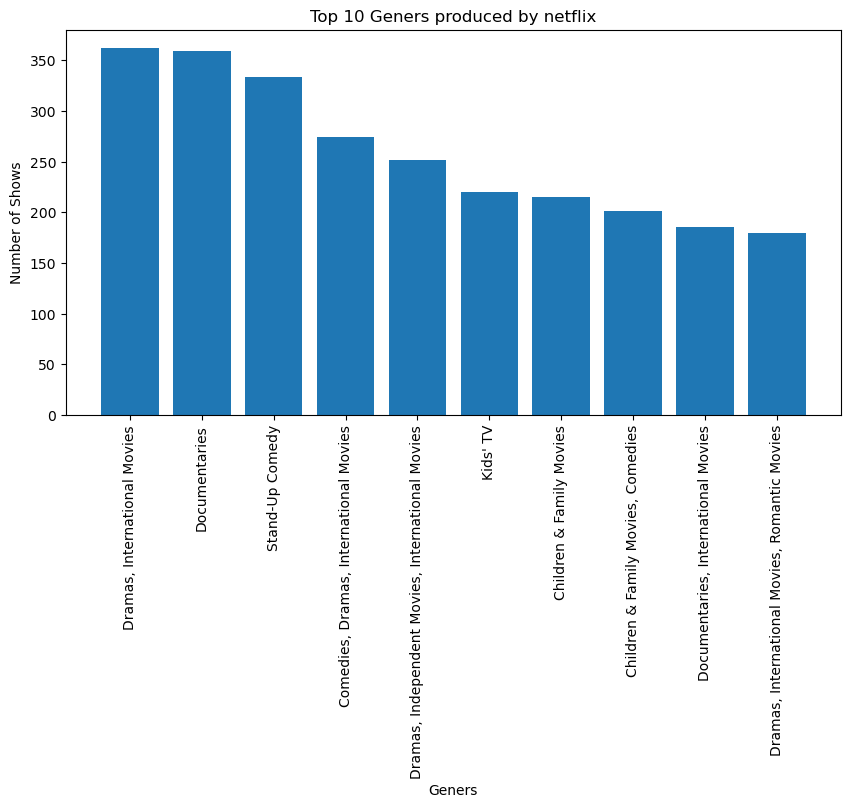

In [19]:
a = data.groupby("listed_in")["show_id"].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(a.index, a.values)
plt.xticks(rotation=90)
plt.title("Top 10 Geners produced by netflix")
plt.xlabel("Geners")
plt.ylabel("Number of Shows")
plt.show()

It shows that peoples love to watch more that geners like (Dramas,International movies),(Documentaries),(Standup comedy) and romance type scenes in top
genere movies or tv shows that produced by netflix in half number of top genere content it shows that people do not like romantic content

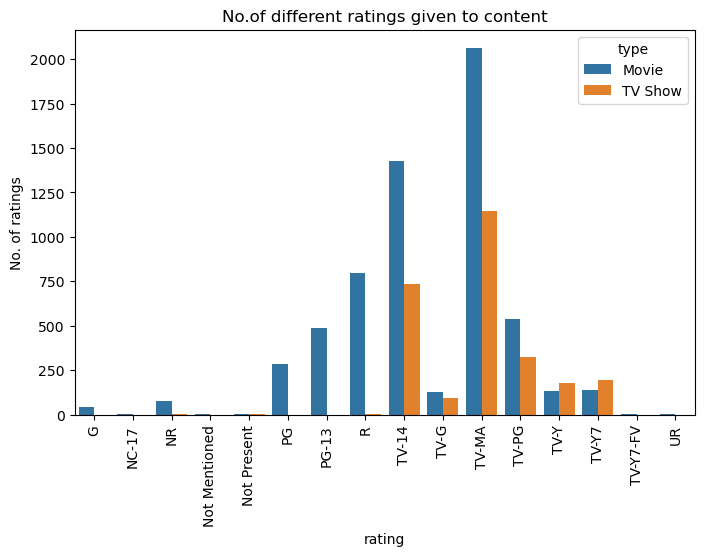

In [20]:
a = data.groupby(["rating", "type"]).agg({"show_id":"count"})
plt.figure(figsize=(8,5))
plt.ylabel("No. of ratings")
plt.title("No.of different ratings given to content")
plt.xticks(rotation=90)
sns.barplot(data=a, x="rating", y="show_id", hue="type")
plt.show()

It shows that most TV-MA rating given for both movies and tv shows some TV-14 rating also given after TV-MA except that all ratings were given in less
number

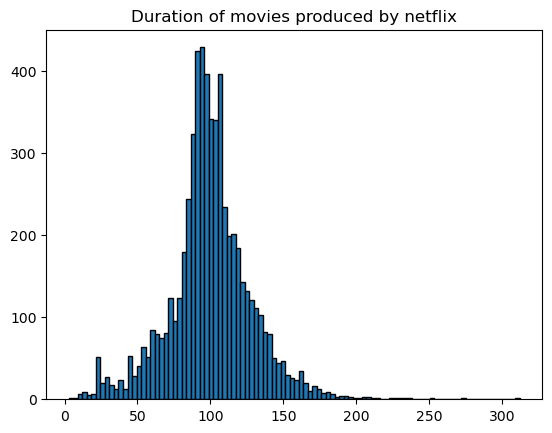

In [35]:
a=data.query("type=='Movie'").copy()
plt.hist(a["duration"],bins=100,edgecolor="black")
plt.title("Duration of movies produced by netflix")
plt.show()

It shows that most movies are of duration 80 to 120 minutes

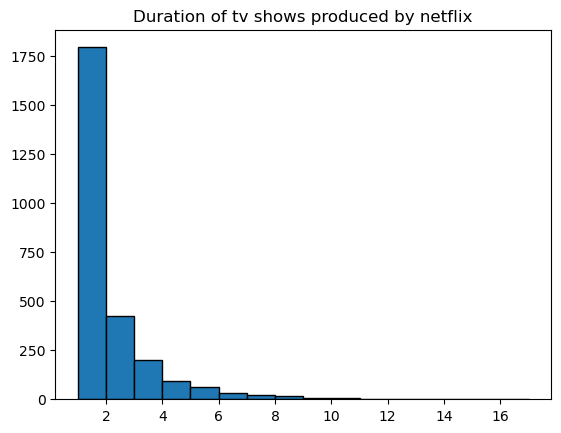

In [31]:
a=data.query("type=='TV Show'").copy()
plt.hist(a["duration"],bins=16,edgecolor="black")
plt.title("Duration of tv shows produced by netflix")
plt.show()

It shows that most tv shows are of 1 seasons and have a little bit of 2 or 3 seasons also